<a href="https://colab.research.google.com/github/gustkt/GE337_Programming_Dev/blob/main/Lab_2_%E0%B8%81%E0%B8%A4%E0%B8%95%E0%B8%A0%E0%B8%B2%E0%B8%AA_6606614615.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 2: การแสดงผลข้อมูลเชิงพื้นที่ด้วย GeoPandas, Matplotlib, Folium
และการวิเคราะห์ข้อมูล Raster ด้วย Rasterio**

**ข้อมูลที่ใช้**

ข้อมูลเวกเตอร์ (Vector Data)
*  ขอบเขตพื้นที่ศึกษาจ.ปัตตานี (Polygon)
*  ตำแหน่งสถานีตรวจวัดอากาศ (Point Data)

ข้อมูลแรสเตอร์ (Raster Data)

*   ข้อมูลภาพถ่ายดาวเทียม Sentinel-2

**การโหลดและเตรียมข้อมูล**




In [1]:
!pip install -q geopandas rasterio folium

In [73]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import numpy as np



*   **นำเข้าและตรวจสอบข้อมูล Shapefile ของจ.ตาก**



In [3]:
# โหลดขอบเขตจังหวัดปัตตานี
Pattani = gpd.read_file('/content/drive/MyDrive/Data for program dev/lab2/Pattani/PTN_bound/32_base2_pattani.shp')

# ตรวจสอบข้อมูล
print(Pattani.head())
print(Pattani.crs)
print(Pattani.geom_type)

               LAYER PROV_CODE PROV_NAMT PROV_NAME  Area_km2_  \
0  Unknown Area Type        94   ปัตตานี   PATTANI    1953.05   

                                            geometry  
0  POLYGON ((101.29297 6.94872, 101.29416 6.94821...  
EPSG:4326
0    Polygon
dtype: object


In [11]:
# โหลดข้อมูลจุดสถานีตรวจวัดอากาศ
stations = gpd.read_file('/content/drive/MyDrive/Data for program dev/lab2/Pattani/PTN_Weather_station/PTN_Wx_sta.shp')

# แสดงข้อมูลเบื้องต้น
print("=== ตัวอย่างข้อมูลสถานี ===")
print(stations.head())

print("\n=== CRS ของสถานี ===")
print(stations.crs)

print("\n=== ประเภท Geometry ===")
print(stations.geom_type.unique())

print("\n=== จำนวนสถานีทั้งหมด ===")
print(len(stations))

=== ตัวอย่างข้อมูลสถานี ===
   Region  Station_ID    SNAME                              FNAME  LATITUDE  \
0       5          85  PATTANI  PATTANI Weather Observing Station  6.783333   

   LONGITUDE  ALT                         geometry  
0     101.15    6  POINT (11259966.494 756887.438)  

=== CRS ของสถานี ===
EPSG:3857

=== ประเภท Geometry ===
['Point']

=== จำนวนสถานีทั้งหมด ===
1


*   **โหลดข้อมูลภาพถ่ายดาวเทียมในรูปแบบ GeoTIFF ด้วย Rasterio**




In [13]:
raster_path = '/content/drive/MyDrive/Data for program dev/lab2/Pattani/PTN_S2/PTN_S2.tif'
src = rasterio.open(raster_path)

*   **แสดง Metadata ของไฟล์ภาพถ่ายดาวเทียม เช่น ค่า Resolution, CRS และ Bands ต่าง ๆ**




In [14]:
# แสดง Metadata
print("=== Raster Metadata ===")
print("CRS:", src.crs)
print("Resolution:", src.res)
print("Width x Height:", src.width, "x", src.height)
print("Number of Bands:", src.count)
print("Bounds:", src.bounds)
print("\n=== Band Descriptions ===")
for i in range(1, src.count + 1):
    print(f"Band {i} name:", src.descriptions[i-1])

=== Raster Metadata ===
CRS: EPSG:32647
Resolution: (10.0, 10.0)
Width x Height: 8298 x 4864
Number of Bands: 4
Bounds: BoundingBox(left=721470.0, bottom=723300.0, right=804450.0, top=771940.0)

=== Band Descriptions ===
Band 1 name: B2
Band 2 name: B3
Band 3 name: B4
Band 4 name: B8


In [18]:
print("CRS Shapefile:",
      "Pattani", Pattani.crs,
      "station", stations.crs )
print("CRS Raster:", src.crs)

CRS Shapefile: Pattani PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]] station EPSG:3857
CRS Raster: EPSG:32647


จากการตรวจสอบพบว่า Shapefile และไฟล์ภาพถ่ายดาวเทียม มี CRS ต่างกัน ดังนั้นจึงต้องทำการแปลง CRS ให้ตรงกัน โดยยึด CRS ของภาพถ่ายดาวเทียมเป็นหลัก

In [19]:
Pattani = Pattani.to_crs(src.crs)
stations = stations.to_crs(src.crs)

print("CRS ใหม่จังหวัดปัตตานี:", Pattani.crs)
print("CRS ใหม่สถานี:", stations.crs)

CRS ใหม่จังหวัดปัตตานี: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]
CRS ใหม่สถานี: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMET

**การสร้างแผนที่ข้อมูลเวกเตอร์**

*   **แสดงขอบเขตพื้นที่จ.ปัตตานีโดยใช้ GeoPandas และ Matplotlib**



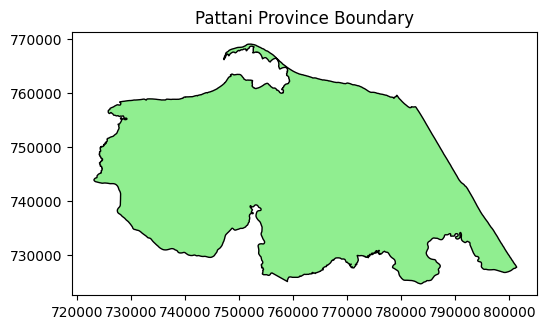

In [20]:
fig, ax = plt.subplots(figsize=(6,6))
Pattani.plot(ax=ax, color='lightgreen', edgecolor='black')
ax.set_title("Pattani Province Boundary")
plt.show()

*   **สร้าง Interactive Map แสดงสถานีตรวจวัดอากาศโดยใช้ Folium**



In [92]:
# แปลง CRS เป็น WGS84 สำหรับ Folium
Pattani_web = Pattani.to_crs(epsg=4326)
stations_web = stations.to_crs(epsg=4326)

# หา center ใหม่
center = Pattani_web.geometry.representative_point().iloc[0]

m = folium.Map(location=[center.y, center.x], zoom_start=8)

folium.GeoJson(Pattani_web).add_to(m)

for _, row in stations_web.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=row.get('FNAME', 'Station'),
        icon=folium.Icon(color="red")
    ).add_to(m)

m

**ลิงก์เปิด Interactive Map ผ่าน GitHub**
https://gustkt.github.io/GE337_Programming_Dev/Pattani_Weather_station_map.html

**การทำงานกับข้อมูล Raster**

*   **ใช้ Rasterio โหลดและแสดงผลภาพถ่ายดาวเทียม**




In [22]:
src = rasterio.open(raster_path)

print("=== Raster Metadata ===")
print("CRS:", src.crs)
print("Resolution:", src.res)
print("Width x Height:", src.width, "x", src.height)
print("Number of Bands:", src.count)
print("Bounds:", src.bounds)
print("\n=== Band Descriptions ===")
for i in range(1, src.count + 1):
    print(f"Band {i} name:", src.descriptions[i-1])

=== Raster Metadata ===
CRS: EPSG:32647
Resolution: (10.0, 10.0)
Width x Height: 8298 x 4864
Number of Bands: 4
Bounds: BoundingBox(left=721470.0, bottom=723300.0, right=804450.0, top=771940.0)

=== Band Descriptions ===
Band 1 name: B2
Band 2 name: B3
Band 3 name: B4
Band 4 name: B8


* **วาดภาพ Band ต่าง ๆ ของภาพถ่ายดาวเทียม**



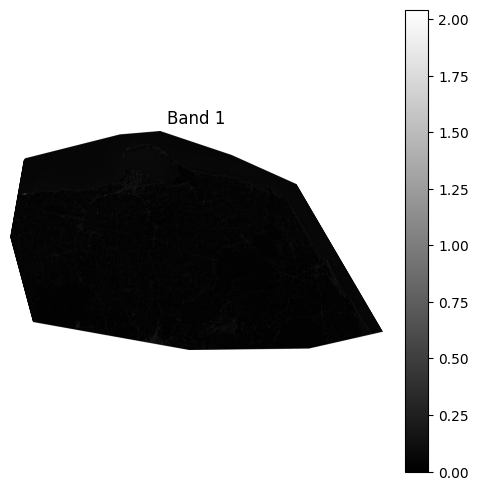

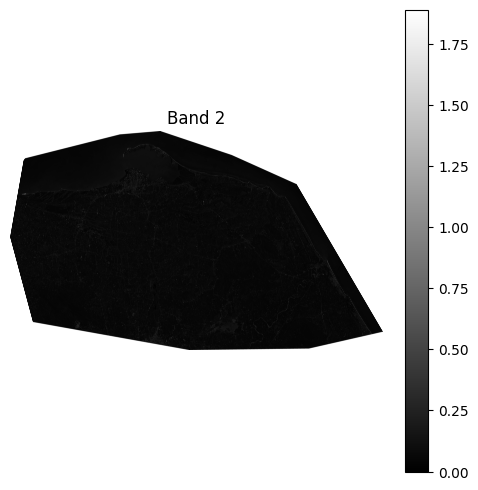

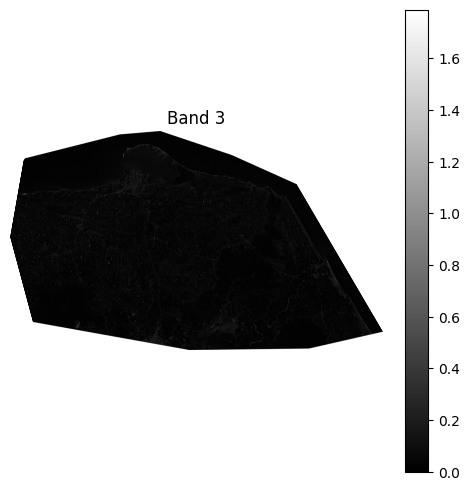

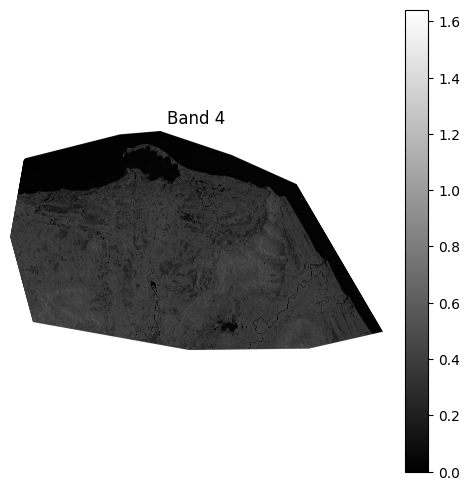

In [23]:
for i in range(1, src.count + 1):
    band = src.read(i)

    plt.figure(figsize=(6,6))
    plt.imshow(band, cmap='gray')
    plt.title(f"Band {i}")
    plt.colorbar()
    plt.axis("off")
    plt.show()

* **การทำ Band Math เช่น NDVI (Normalized Difference Vegetation Index) สำหรับการวิเคราะห์พื้นที่สีเขียว**

/tmp/ipython-input-1592053837.py:8: RuntimeWarning: invalid value encountered in subtract
  (nir - red) / (nir + red)


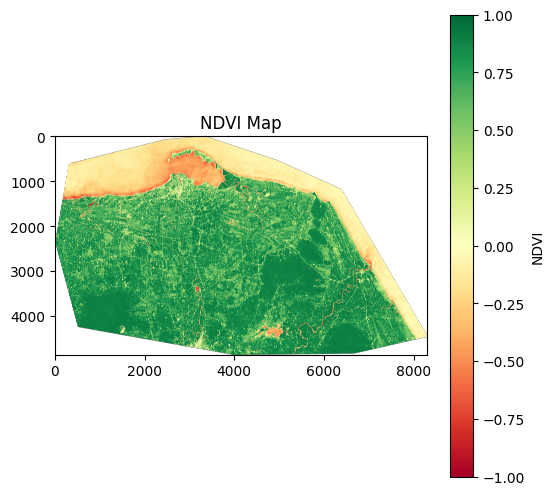

In [24]:
red = src.read(3).astype(float) #Band 4 ใน Sentinel-2 แต่อยู่ใน Band 3 ของไฟล์ภาพถ่ายดาวเทียม
nir = src.read(4).astype(float) #Band 8 ใน Sentinel-2 แต่อยู่ใน Band 4 ของไฟล์ภาพถ่ายดาวเทียม

# ป้องกันการหารศูนย์
ndvi = np.where(
    (nir + red) == 0,
    np.nan,
    (nir - red) / (nir + red)
)

plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI Map")
plt.show()

In [30]:
# Save ลงใน Google Drive
output_path = "/content/drive/MyDrive/Data for program dev/lab2/NDVI_Map.tif"

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=ndvi.shape[0],
    width=ndvi.shape[1],
    count=1,
    dtype=ndvi.dtype,
    crs=src.crs,
    transform=src.transform,
) as dst:
    dst.write(ndvi, 1)

print("Saved to Drive")

Saved to Drive


* **ตัดภาพถ่ายดาวเทียมให้ตรงกับพื้นที่ศึกษา (จ.ปัตตานี) โดยใช้ Masking และ Clipping**

In [31]:
# โหลดภาพ NDVI จาก Google Drive
ndvi_path = "/content/drive/MyDrive/Data for program dev/lab2/NDVI_Map.tif"
src = rasterio.open(ndvi_path)

In [32]:
# ตรวจสอบ CRS ให้ตรงกัน
print("Raster CRS:", src.crs)
print("Vector CRS:", Pattani.crs)

if Pattani.crs != src.crs:
    Pattani = Pattani.to_crs(src.crs)

Raster CRS: EPSG:32647
Vector CRS: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]


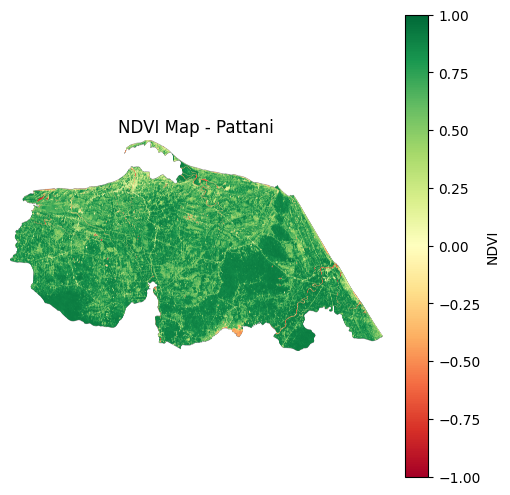

In [38]:
geoms = Pattani.geometry.values

clipped_ndvi, clipped_transform = mask(
    src,
    geoms,
    crop=True,
    filled=False

)

plt.figure(figsize=(6,6))
plt.imshow(clipped_ndvi[0], cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI Map - Pattani")
plt.axis("off")
plt.show()

In [39]:
# Save NDVI ที่ผ่าน Masking และ Clipping แล้วลงใน Google Drive
output_path = "/content/drive/MyDrive/Data for program dev/lab2/Pattani/NDVI_Pattani.tif"

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=clipped_ndvi.shape[1],
    width=clipped_ndvi.shape[2],
    count=1,
    dtype=clipped_ndvi.dtype,
    crs=src.crs,
    transform=clipped_transform,
) as dst:
    dst.write(clipped_ndvi)

print("NDVI_Pattani saved")

NDVI_Pattani saved


**การรวมข้อมูลเวกเตอร์และแรสเตอร์**

* **ซ้อนทับข้อมูลเวกเตอร์และแรสเตอร์เพื่อดูความสัมพันธ์ เช่น
ตำแหน่งสถานีตรวจวัดอากาศกับค่าการสะท้อนแสงของพืชพรรณ**

In [40]:
# ตรวจสอบ CRS ให้ตรงกัน
print("Raster CRS:", src.crs)
print("Stations CRS:", stations.crs)

if stations.crs != src.crs:
    stations = stations.to_crs(src.crs)

Raster CRS: EPSG:32647
Stations CRS: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]


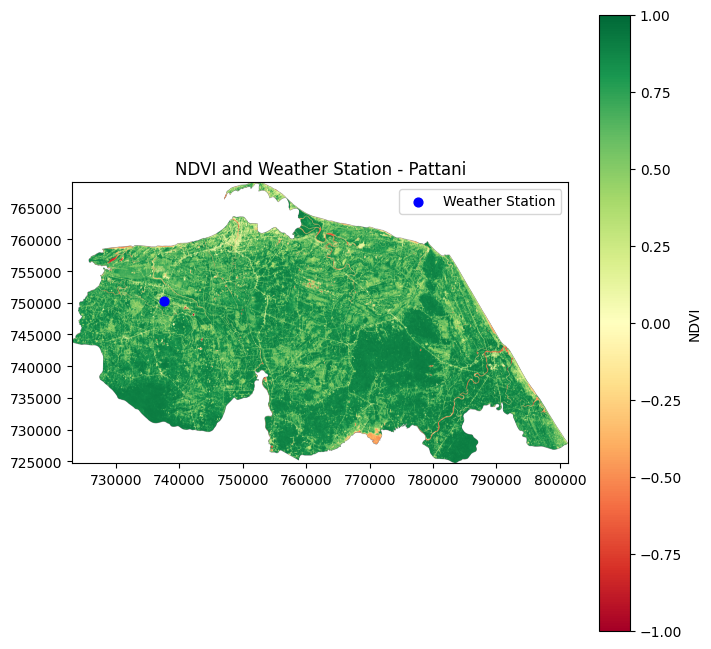

In [43]:
fig, ax = plt.subplots(figsize=(8,8))

ndvi_plot = ax.imshow(
    clipped_ndvi[0],
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    extent=(
        clipped_transform[2],
        clipped_transform[2] + clipped_transform[0]*clipped_ndvi.shape[2],
        clipped_transform[5] + clipped_transform[4]*clipped_ndvi.shape[1],
        clipped_transform[5]
    )
)

stations.plot(ax=ax, color='blue', markersize=40, label='Weather Station')

plt.colorbar(ndvi_plot, ax=ax, label="NDVI")
plt.legend()
plt.title("NDVI and Weather Station - Pattani")
plt.show()

In [45]:
# ดึงค่า NDVI ที่ตำแหน่งสถานี
coords = [(geom.x, geom.y) for geom in stations.geometry]

ndvi_values = list(src.sample(coords))

stations["NDVI_value"] = [val[0] for val in ndvi_values]

stations[["NDVI_value"]]

,NDVI_value
0,0.437105


* **คำนวณค่าสถิติเบื้องต้นของค่า Pixel ภายในพื้นที่จ.ปัตตานี**

In [46]:
# ดึง band ออกมา
ndvi_array = clipped_ndvi[0]

# เอาเฉพาะค่าที่ไม่ใช่ NaN
valid_pixels = ndvi_array[~np.isnan(ndvi_array)]

print("Number of valid pixels:", valid_pixels.size)
print("Minimum NDVI:", np.min(valid_pixels))
print("Maximum NDVI:", np.max(valid_pixels))
print("Mean NDVI:", np.mean(valid_pixels))
print("Median NDVI:", np.median(valid_pixels))
print("Standard Deviation:", np.std(valid_pixels))

Number of valid pixels: 28704685
Minimum NDVI: -1.0
Maximum NDVI: 1.0
Mean NDVI: 0.71543466866571


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Median NDVI: 0.7595408851832626
Standard Deviation: 0.237463865538884


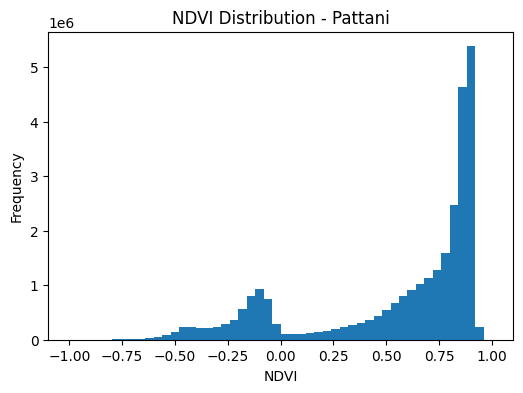

In [48]:
# สร้าง Histogram ของ NDVI ในปัตตานี
plt.figure(figsize=(6,4))
plt.hist(valid_pixels, bins=50)
plt.xlabel("NDVI")
plt.ylabel("Frequency")
plt.title("NDVI Distribution - Pattani")
plt.show()

**การแสดงผลข้อมูล**

* **แสดงแผนที่ข้อมูลเวกเตอร์พร้อมกับข้อมูลแรสเตอร์โดยใช้ Matplotlib**

In [49]:
# ตรวจสอบ CRS ให้ตรงกัน
print("Raster CRS:", src.crs)
print("Vector CRS:", Pattani.crs)

if Pattani.crs != src.crs:
    Pattani = Pattani.to_crs(src.crs)

if stations.crs != src.crs:
    stations = stations.to_crs(src.crs)

Raster CRS: EPSG:32647
Vector CRS: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]


In [50]:
ndvi_array = clipped_ndvi[0]

# คำนวณขอบเขตภาพ
left = clipped_transform[2]
top = clipped_transform[5]
right = left + clipped_transform[0] * ndvi_array.shape[1]
bottom = top + clipped_transform[4] * ndvi_array.shape[0]

extent = [left, right, bottom, top]

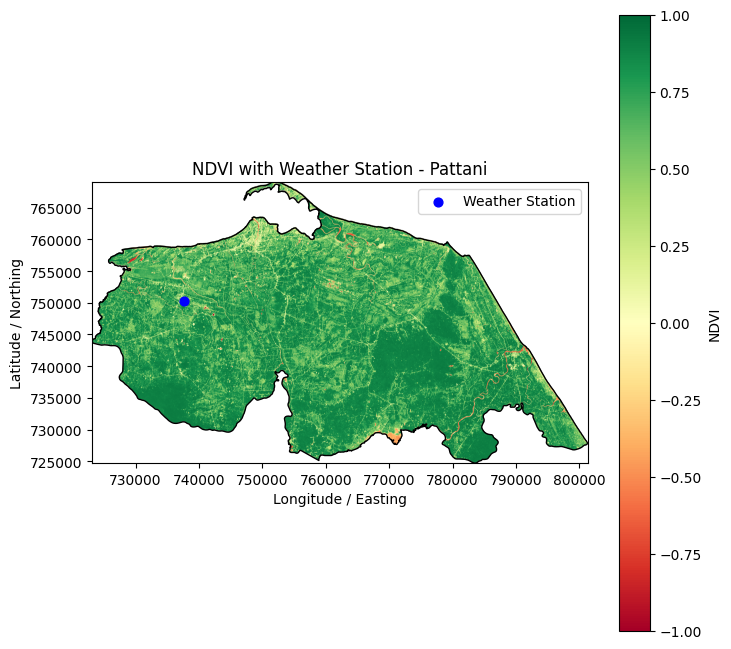

In [52]:
fig, ax = plt.subplots(figsize=(8,8))

# แสดง NDVI
img = ax.imshow(
    ndvi_array,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    extent=extent
)

# แสดงขอบเขตจังหวัด
Pattani.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# แสดงจุดสถานี
stations.plot(ax=ax, color='blue', markersize=40, label='Weather Station')

# เพิ่ม colorbar
plt.colorbar(img, ax=ax, label='NDVI')

plt.legend()
plt.title("NDVI with Weather Station - Pattani")
plt.xlabel("Longitude / Easting")
plt.ylabel("Latitude / Northing")
plt.show()

* **แสดงผลข้อมูลจุดร่วมกับภาพพื้นหลังจากภาพถ่ายดาวเทียมโดยใช้ Folium**

In [54]:
# แปลง CRS เป็น EPSG:4326
if stations.crs != "EPSG:4326":
    stations = stations.to_crs(epsg=4326)

In [57]:
# หาค่ากลางของพื้นที่เพื่อใช้เป็น center
center = [stations.geometry.y.mean(), stations.geometry.x.mean()]

m = folium.Map(
    location=center,
    zoom_start=10,
    tiles=None
)

# เพิ่มภาพถ่ายดาวเทียม
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

# เพิ่มจุดสถานีตรวจอากาศ
folium.LayerControl().add_to(m)
for _, row in stations_web.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=row.get('FNAME', 'Station'),
        icon=folium.Icon(color="red")
    ).add_to(m)
m

**ลิงก์เปิด Interactive Map ผ่าน GitHub**
https://gustkt.github.io/GE337_Programming_Dev/Pattani_Weather_Station_map_Satellite.html

* **สร้างแผนที่ NDVI เพื่อวิเคราะห์พื้นที่สีเขียว**

In [65]:
# ตรวจสอบ CRS ให้ตรงกัน
print("Raster CRS:", src.crs)
print("Vector CRS:", Pattani.crs)

if Pattani.crs != src.crs:
    Pattani = Pattani.to_crs(src.crs)

if stations.crs != src.crs:
    stations = stations.to_crs(src.crs)

Raster CRS: EPSG:32647
Vector CRS: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]


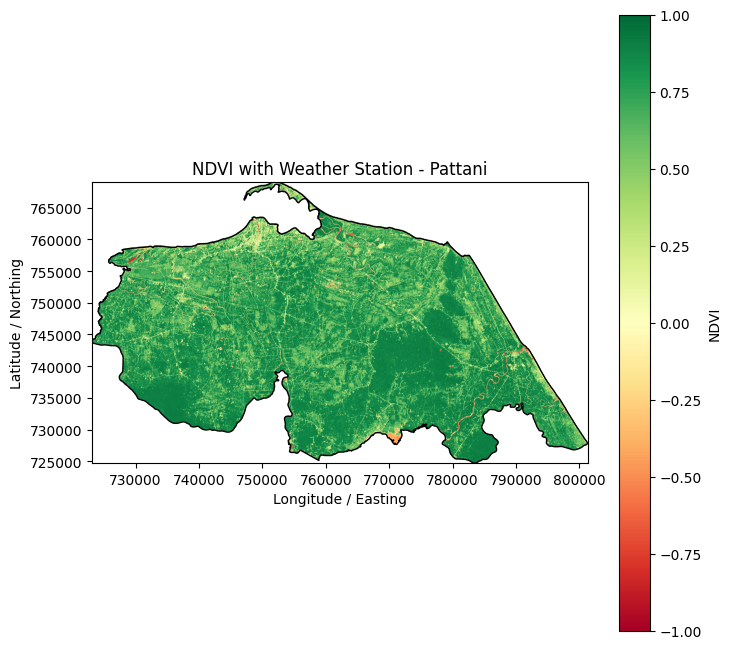

In [68]:
ndvi_array = clipped_ndvi[0]

# คำนวณขอบเขตภาพ
left = clipped_transform[2]
top = clipped_transform[5]
right = left + clipped_transform[0] * ndvi_array.shape[1]
bottom = top + clipped_transform[4] * ndvi_array.shape[0]

extent = [left, right, bottom, top]

fig, ax = plt.subplots(figsize=(8,8))

# แสดง NDVI
img = ax.imshow(
    ndvi_array,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    extent=extent
)

# แสดงขอบเขตจังหวัด
Pattani.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# เพิ่ม colorbar
plt.colorbar(img, ax=ax, label='NDVI')
plt.title("NDVI with Weather Station - Pattani")
plt.xlabel("Longitude / Easting")
plt.ylabel("Latitude / Northing")
plt.show()

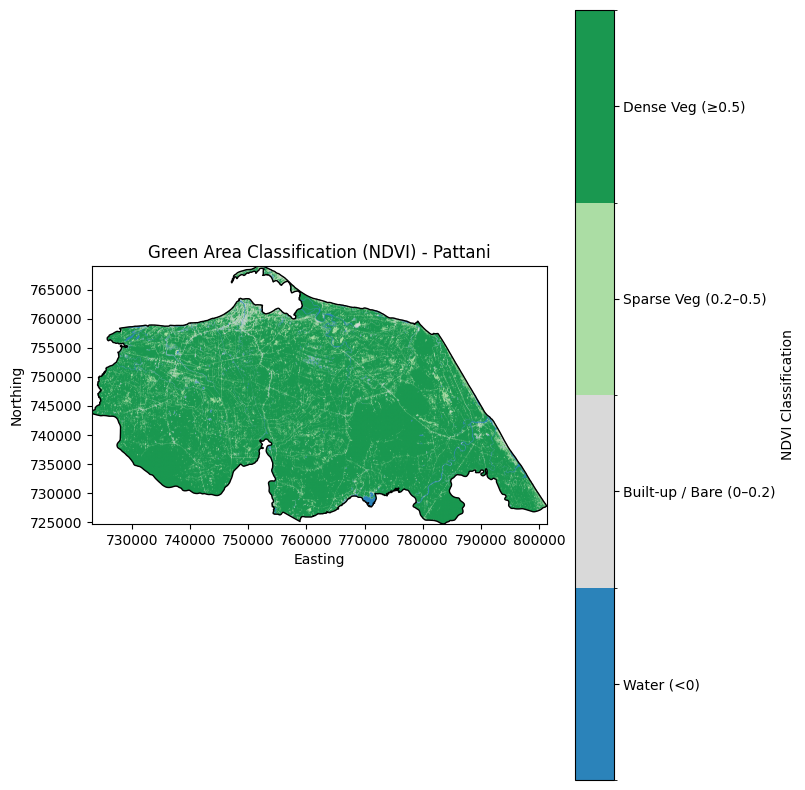

In [76]:
# แสดงแผนที่จำแนกพื้นที่สีเขียว
# กำหนดสี
colors = [
    "#2b83ba",  # 0 น้ำ (น้ำเงิน)
    "#d9d9d9",  # 1 เมือง/พื้นที่โล่ง (เทา)
    "#abdda4",  # 2 พืชเบาบาง (เขียวอ่อน)
    "#1a9850"   # 3 พืชหนาแน่น (เขียวเข้ม)
]

cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8,8))

img = ax.imshow(
    classified,
    cmap=cmap,
    norm=norm,
    extent=extent
)

Pattani.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# discrete colorbar
cbar = plt.colorbar(img, ax=ax, ticks=[0,1,2,3])
cbar.set_ticklabels([
    "Water (<0)",
    "Built-up / Bare (0–0.2)",
    "Sparse Veg (0.2–0.5)",
    "Dense Veg (≥0.5)"
])

cbar.set_label("NDVI Classification")

plt.title("Green Area Classification (NDVI) - Pattani")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.tight_layout()
plt.show()

In [85]:
valid_pixels = classified.compressed()

total_pixels = valid_pixels.size
green_pixels = np.sum((valid_pixels == 2) | (valid_pixels == 3))

green_ratio = (green_pixels / total_pixels) * 100

print(f"Green area (NDVI >= 0.2) = {green_ratio:.2f} %")

Green area (NDVI >= 0.2) = 96.07 %


**คำถามท้าย Lab**

**1. ข้อดีและข้อเสียของการใช้ Matplotlib และ Folium ในการแสดงผลข้อมูลเชิงพื้นที่คืออะไร?**

***คำตอบ*** Matplotlib มีข้อดี คือ   
1. เราสามารถตั้งค่าการแสดงผลได้ละเอียด
เช่น สี,scale,legend เป็นต้น
2. เหมาะกับงานวิเคราะห์เชิงปริมาณ เช่น NDVI, Histogram
3. ทำงานร่วมกับ Rasterio และ Geopandas ได้ดี
4. เหมาะกับการทำภาพใส่รายงานหรือบทความวิชาการ

ส่วนข้อเสีย ได้แก่
1. เลื่อน/ซูม หรือคลิกไม่ได้
2. ไม่เหมาะกับการนำไปแสดงผลผ่านเว็บ
3. การจัดการ basemap ทำได้ยาก

Folium มีข้อดี คือ   
1. สามารถซูม หรือที่เรียกว่า Interactive ได้
2. แสดงผลบน Web map ได้ทันที
3. ใช้ basemap จาก OSM หรือ Esri ได้ง่าย
4. เหมาะกับการนำเสนอ และสื่อสารผลลัพธ์ให้เห็นชัด

ส่วนข้อเสีย ได้แก่
1. ไม่เหมาะกับข้อมูล Raster ขนาดใหญ่
2. ปรับแต่งการวิเคราะห์เชิงลึกได้อย่างจำกัด
3. ประสิทธิภาพลดลงเมื่อมีข้อมูลจุดจำนวนมาก

**2. ทำไมเราต้องใช้ Masking และ Clipping ในการวิเคราะห์ข้อมูลภาพถ่ายดาวเทียม?**

***คำตอบ*** เพื่อลดพื้นที่การวิเคราะห์ให้ตรงกับขอบเขตการศึกษา, เป็นการลดขนาดข้อมูล ทำให้ประมวลผลเร็วขึ้น, ป้องกันค่า error จากพื้นที่นอกขอบเขต และทำให้ค่าทางสถิติ เช่น Mean, Min, Max มีค่าถูกต้องตามเฉพาะพื้นที่ที่สนใจ

**3. ค่า NDVI บ่งบอกถึงอะไร? และสามารถใช้ NDVI ในการวิเคราะห์อะไรได้บ้าง?**

***คำตอบ*** NDVI (Normalized Difference Vegetation Index) บ่งบอกถึงความสมบูรณ์ ความหนาแน่น และสุขภาพของพืชสีเขียว หลัก ๆ สามารถใช้วิเคราะห์เกี่ยวกับพื้นที่สีเขียวต่าง ๆ เช่น ความหนาแน่นของพืชพรรณ, การเปลี่ยนแปลงพื้นที่ป่า/พื้นที่เกษตร เป็นต้น

**4. การแปลงค่าพิกัด (CRS) มีความสำคัญอย่างไรในการทำงานกับข้อมูลเวกเตอร์และแรสเตอร์?**

***คำตอบ*** เนื่องจาก CRS มีผลโดยตรงเกี่ยวกับความถูกต้องของตำแหน่ง การซ้อนทับข้อมูล และการคำนวณระยะทาง/พื้นที่ ถ้า CRS ไม่ตรงกันส่งผลให้ข้อมูล Vector และ Raster ซ้อนกันไม่ตรงหรือตำแหน่งผิดเพี้ยนทำให้คำนวณพื้นที่ผิดพลาด หรือวิเคราะห์ดัชนี เช่น NDVI ผิดตำแหน่งได้

**5. หากต้องการวิเคราะห์ข้อมูลภาพถ่ายดาวเทียมในช่วงเวลาต่าง ๆ (Time Series) ควรทำอย่างไร?**

***คำตอบ*** การวิเคราะห์ข้อมูลภาพถ่ายดาวเทียมในช่วงเวลาต่าง ๆ (Time Series) อาจทำได้ตามขั้นตอน ดังนี้
1. รวบรวมภาพจากหลายวันตามวันที่ต้องการศึกษา
2. ทำ Preprocessing ภาพให้เหมือนกันทุกภาพ (CRS, Resolution และ Clip/Masking ต้องเหมือนกัน)
3. วิเคราะห์ดัชนีตามหัวข้อที่ศึกษา เช่น วิเคราะห์ NDVI ต้องทำการคำนวณ NDVI ของทุกช่วงเวลา
4. สร้าง stack หรือ array ของ NDVI
5. วิเคราะห์แนวโน้ม เช่น เปรียบเทียบค่าเฉลี่ยรายเดือน/รายปี, สร้างกราฟแนวโน้ม, ใช้ Linear regression หาแนวโน้ม เป็นต้น

